<h1 style = "color : #0EE071; text-align : center;"><em>Nata Project</em> - Feature Management Notebook</h1>
<p style = "font-size : 16px; text-align: center;">This notebook has the funcion of preparing the features for the learning model.</p>
<br>
<p style = "font-size : 12px; text-align: center;"><b>NOVA IMS</b></p>
<p style = "font-size : 10px; text-align: center;">Machine Learning I</p>
<p style = "font-size : 10px; text-align: center;">Diogo Gonçalves, João Marques, Juan Mendes, Gustavo Franco & Lucas Casimiro</p>
<br>


## <a class="anchor" id="0th-bullet">Table of Contents</a>


* [<b>1. Preparation</b>](#1st-bullet)<br>
    * [1.1 Import the needed libraries and datasets](#2nd-bullet)<br>
    * [1.2 Scaling](#4.5th-bullet)<br>
    
    
* [<b>2. Feature Selection</b>](#5th-bullet)<br>
    * [2.1 Handling Multicolinearity](#6th-bullet)<br>
    * [2.2 Filter methods](#6th-bullet)<br>
        * 2.2.1 Constant features<br>
        * 2.2.2 Spearman Correlation<br>
        * 2.2.3 Chi-Square Test<br>
    * [2.3 Wrapper Methods](#10th-bullet)<br>
        * 2.2.1 RFE<br>
    * [2.4 Embedded Methods](#12th-bullet)<br>
        * 2.3.1 Lasso Regression<br>
        * 2.3.2 Decision Tree<br>
    * [2.5 Final Insights](#15th-bullet)<br>


<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 1. Preparation</h2>
<h3 style="color: #0EE071;">1.1 Import the needed libraries and datasets</h3>


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

import scipy.stats as stats
from scipy.stats import chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

In [44]:
X_train = pd.read_pickle('Nata_files/data_clean/X_train_clean.pkl')
X_val = pd.read_pickle('Nata_files/data_clean/X_val_clean.pkl')
y_train = pd.read_pickle('Nata_files/data_clean/y_train_clean.pkl')
y_val = pd.read_pickle('Nata_files/data_clean/y_val_clean.pkl')

In [45]:
X_train

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto
id,,,,,,,,,,,,,,
4144,57.0,21.0,20.0,98.0,83.000000,9.0,331.0,3.0,335.0,195.0,66.53,11.1,5.1,False
1193,43.0,23.0,49.0,99.7,20.000000,11.0,80.0,3.0,70.0,306.0,50.39,18.0,7.9,True
909,57.0,17.0,31.0,97.2,57.946547,11.0,292.0,3.0,293.0,230.0,47.00,12.0,5.0,False
4667,77.0,17.0,28.0,93.1,52.000000,10.0,220.0,3.1,222.0,185.0,43.11,17.7,3.6,False
4899,54.0,40.0,8.0,97.0,16.000000,13.0,60.0,3.2,61.0,237.0,58.45,26.0,3.8,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,70.0,27.0,32.0,99.1,49.000000,12.0,161.0,3.3,171.0,189.0,33.57,45.5,5.8,False
233,79.0,25.0,26.0,97.9,100.000000,13.0,256.0,3.1,275.0,209.0,37.55,23.6,3.6,False
5081,50.0,25.0,23.0,97.9,95.000000,9.0,343.0,3.6,358.0,199.0,60.56,12.9,4.9,False


<h3 style="color: #0EE071;">1.2 Feature Scaling</h3>
<p style = "font-size : 15px;">To optimize our model, we must address the different scales and distributions of our data. In this section, we'll apply Standard Scaling to center all numerical variables at a mean of 0 and variance of 1. This prevents features with larger magnitudes from dominating the model's learning process.</p>

Note: the dataset has only 1 categorical variable, so we didn't create datasets for a singular column.

In [46]:
# Selecting only numerical columns for scaling
X_train_n = X_train.select_dtypes(include=['int64','float64'])
X_val_n = X_val.select_dtypes(include=['int64','float64'])

# Defining the scaler
scaler = RobustScaler()

# Fitting only the training data and transforming both 
X_train_n_scl = scaler.fit_transform(X_train_n)
X_train_n_scl = pd.DataFrame(X_train_n_scl, columns=X_train_n.columns)

X_val_n_scl = scaler.transform(X_val_n)
X_val_n_scl = pd.DataFrame(X_val_n_scl, columns=X_val_n.columns)

<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 2. Feature Selection</h2>

<h3 style="color: #0EE071;">2.1 Handling Multicolinearity</h3>


As seen in the correlation heatmap in NB1, we see 'oven_temperature' and 'final_temperature' have an extremely high correlation, which means having both is redundant, so we will check for their correlation with the target variable and make a decision to drop the one with the lowest value before getting into the filter methods.

In [47]:
# Correlation analysis before dropping features
analysis_corr = pd.DataFrame(X_train_n_scl, columns=X_train_n.columns)[['oven_temperature', 'final_temperature']].copy()
analysis_corr['quality_class'] = y_train.values

corr_oven = analysis_corr['oven_temperature'].corr(analysis_corr['quality_class'])
corr_final = analysis_corr['final_temperature'].corr(analysis_corr['quality_class'])

print(f"Correlation (Oven Temp vs Target): {corr_oven}")
print(f"Correlation (Final Temp vs Target): {corr_final}")


Correlation (Oven Temp vs Target): -0.05763940542605696
Correlation (Final Temp vs Target): -0.062156860429917825


We conclude that the 'final_temperature' column has a higher absolute correlation, which means it has a better chance of helping to predict the target variable. So, we will drop 'oven_temperature'.

In [48]:
X_train.drop('oven_temperature', axis=1, inplace=True)
X_val.drop('oven_temperature', axis=1, inplace=True)

X_train_n_scl.drop('oven_temperature', axis=1, inplace=True)
X_val_n_scl.drop('oven_temperature', axis=1, inplace=True)

<h3 style="color: #0EE071;">2.2 Filter methods</h3>

### 2.2.1 Constant Features

In [49]:
X_train_n_scl.var().sort_values()

ambient_humidity     0.337547
final_temperature    0.505099
egg_temperature      0.535337
lemon_zest_ph        0.683389
salt_ratio           0.748729
vanilla_extract      0.760415
cream_fat_content    0.801421
sugar_content        0.835542
baking_duration      0.857251
preheating_time      0.961672
cooling_period       1.066615
egg_yolk_count       1.576161
dtype: float64

We conclude that all variables in the dataset exhibit non-zero variance, indicating diversity and variability in their values, so no measures need to be taken.

### 2.1.2. Spearman Correlation

We will now examine the Spearman correlation between variables.  To facilitate this analysis, a new dataframe has been created using all the training data, including the dependent variable. This inclusion allows us to investigate whether any of the independent variables exhibit correlations with the target variable. 



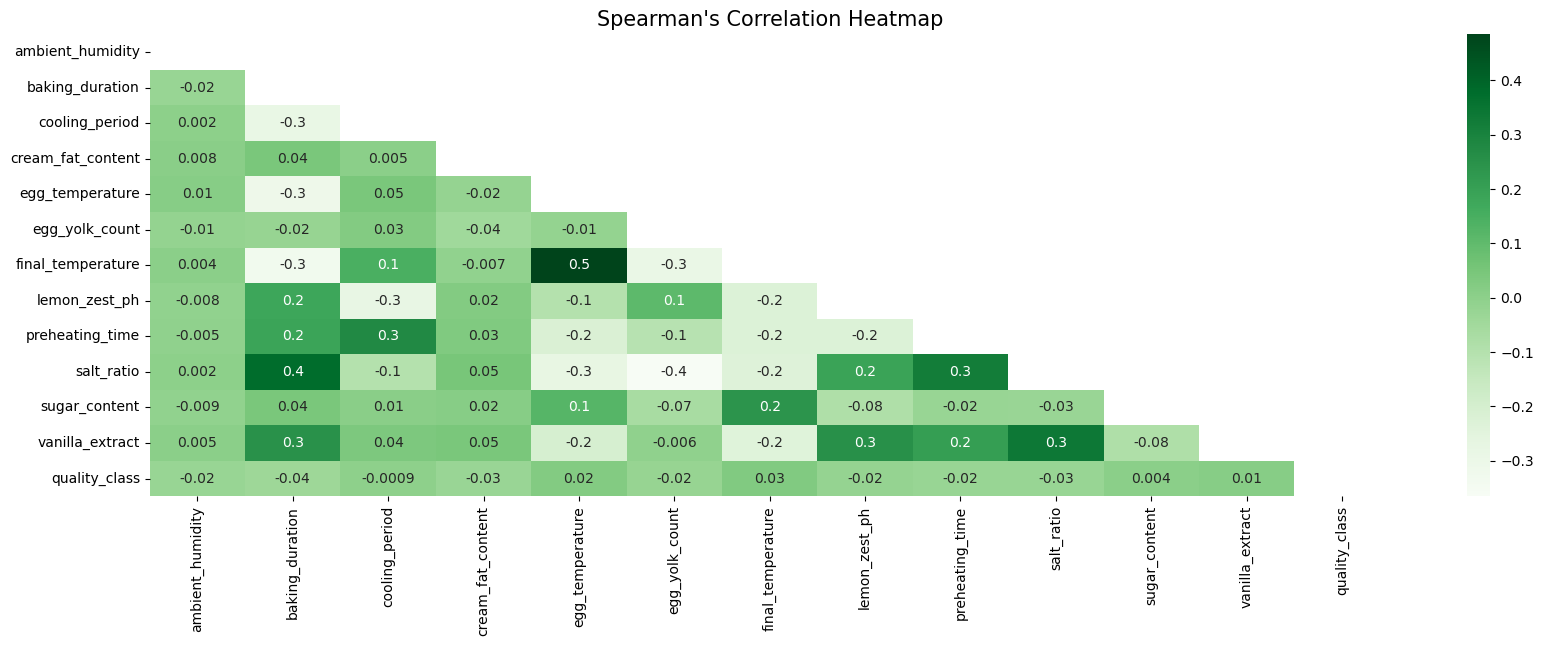

In [50]:
# Joining numerical features and target for correlation analysis
all_train_numerical = X_train_n_scl.join(y_train)

# Computing Spearman's Correlation
correlation = all_train_numerical.corr(method = 'spearman')

# Plotting the lower triangle of the correlation map
def corr_heatmap(correlation):
    plt.figure(figsize=(20, 6))
    ax = sns.heatmap(data = correlation, annot = True, mask = np.triu(np.ones_like(correlation)), cmap = 'Greens', fmt = '.1')
    ax.set_title("Spearman's Correlation Heatmap", fontdict = {'fontsize': 15})
    plt.show()

corr_heatmap(correlation)

We conclude that there are no indendent variables highly correlated with the target variable. However, there is a significant and subtle correlation between 'final_temperature' and 'egg_temperature', which makes logical sense.

Given the absence of strong correlations, it's essential to apply other feature selection methods to gain deeper insights from the dataset.

### 2.1.3. Chi-Square Test

Now, we shift our focus to check for independence on the categorical features with the Chi-Square Test, with a 5% significance level. 

In [51]:
def TestIndependence(X, y,var, alpha=0.05):
    dfObserved = pd.crosstab(y,X) 
    chi2, p, dof, expected = stats.chi2_contingency(dfObserved.values)
    dfExpected = pd.DataFrame(expected, columns=dfObserved.columns, index = dfObserved.index)
    if p < alpha:
        result="{0} is IMPORTANT for Prediction".format(var)
    else:
        result="{0} is NOT an important predictor. (Discard {0} from model)".format(var)
    print(result)

For this method, as we only have 1 categorical feature ('origin_porto', which is binarily encoded), we will use a list with this specific case.

In [53]:
cat_variable = ['origin_porto']
for variable in cat_variable:
    TestIndependence(cat_variable, y_train, variable)

origin_porto is NOT an important predictor. (Discard origin_porto from model)


Based on the Chi-Square result, it is recommended to exclude the 'origin_porto' feature.

<h3 style="color: #0EE071;">2.3 Wrapper methods</h3>

In this section we will apply a wrapper method for feature selection. These aim to identify the most impactful subset of features by training different predictive models with varying feature combinations and comparing their performances. We will start by initializing our model.



In [54]:
model = LogisticRegression()

### 2.3.1 RFE

Recursive Feature Elimination will help selecting the most important features to keep.

In [56]:
# Number of features
nof_list = np.arange(1,8)
high_score = 0

# Variable to store the optimum features
nof = 0
score_list = []
for n in range(len(nof_list)):
    rfe = RFE(model,n_features_to_select = nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train_n_scl,y_train)
    X_val_rfe = rfe.transform(X_val_n_scl)
    model.fit(X_train_rfe,y_train)

    score = model.score(X_val_rfe,y_val)
    score_list.append(score)

    if(score > high_score):
        high_score = score
        nof = nof_list[n]

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

Optimum number of features: 5
Score with 5 features: 0.747115


The optimum number of features for this method is 5. So, 5 features will be selected by the RFE model.

In [60]:
rfe = RFE(estimator = model, n_features_to_select = nof)
rfe.fit_transform(X_train_n_scl, y_train)
selected_features = pd.Series(rfe.support_, index = X_train_n_scl.columns)
print(f"Features to keep:\n{selected_features}")

Features to keep:
ambient_humidity     False
baking_duration       True
cooling_period       False
cream_fat_content    False
egg_temperature       True
egg_yolk_count        True
final_temperature     True
lemon_zest_ph        False
preheating_time      False
salt_ratio           False
sugar_content        False
vanilla_extract       True
dtype: bool


<h3 style="color: #0EE071;">2.4 Embedded methods</h3>

We also used Embedded Methods. This technique involves selecting features during the training of predictive models, taking into account their importance.

### 2.4.1 Lasso Regression

The following function was taken from the Machine Learning classes and serves the purpose of constructing a visualization for the feature importance.

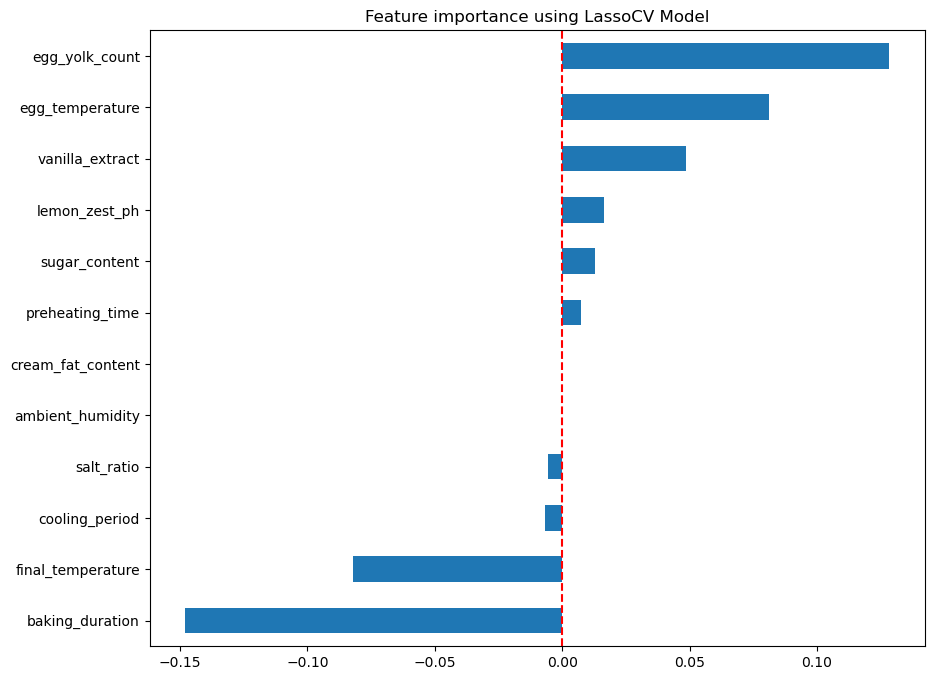

In [63]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(10,8))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()

reg = LassoCV()
reg.fit(X_train_n_scl, y_train)
coef = pd.Series(reg.coef_, index = X_train_n_scl.columns)
plot_importance(coef, 'LassoCV')

According to the Lasso Regression, we should discard the 'cream_fat_content' and 'ambient_humidity' columns, as they seem insignificant for the definition of the target when compared to the other variables.

### 2.4.2 Decision tree

While Lasso Regression is great for eliminating features with no linear correlation with the target, it may incorrectly discard features that are useful only in non-linear thresholds or specific combinations. 

For this, we will use a Decision Tree, to address potential ties and limit ambiguity.

<Axes: xlabel='Value', ylabel='Features'>

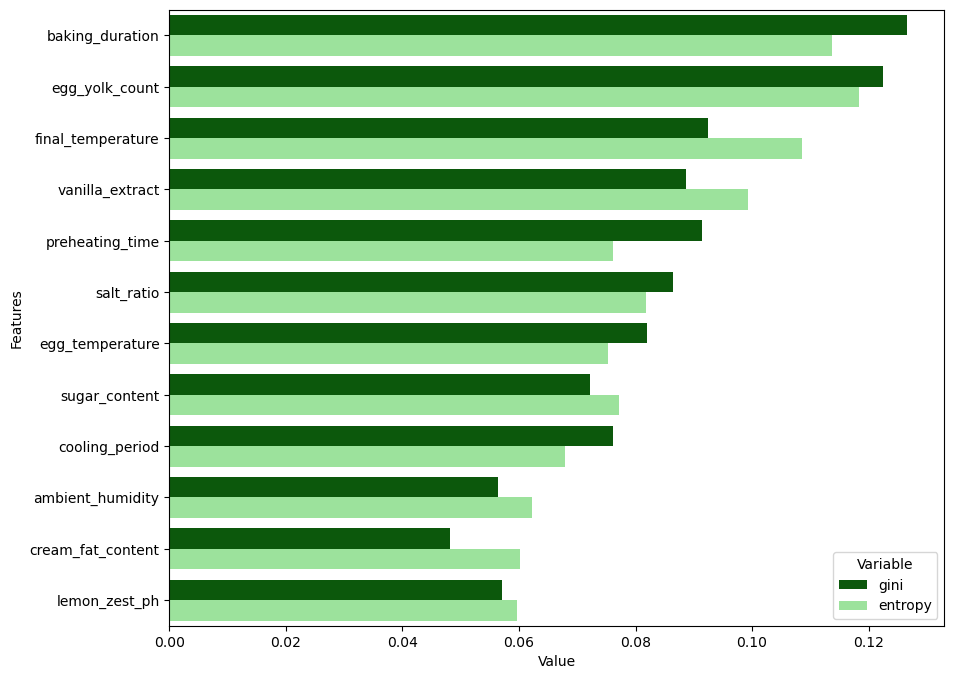

In [69]:
gini_importance = DecisionTreeClassifier(splitter='random', random_state=42).fit(X_train_n_scl, y_train).feature_importances_
entropy_importance = DecisionTreeClassifier(criterion='entropy', splitter='random', random_state=42).fit(X_train_n_scl, y_train).feature_importances_

zippy = pd.DataFrame(zip(gini_importance, entropy_importance), columns=['gini', 'entropy'])
zippy['Features'] = X_train_n_scl.columns
tidy = zippy.melt(id_vars='Features').rename(columns=str.title)
tidy.sort_values(['Value'], ascending=False, inplace=True)

plt.figure(figsize=(10, 8))
sns.barplot(y='Features', x='Value', hue='Variable', data=tidy, palette=['darkgreen', 'lightgreen'])

<h3 style="color: #0EE071;">2.5 Final Insights</h3>